<h1>Train — AlexNet</h1>

Trains and evaluates AlexNet **from scratch (no ImageNet pretraining)** using the hand-picked hyperparameters from `ARCH_HYPERPARAMS["alexnet"]`, then saves its results and weights to disk for the results notebook. Unlike every other architecture here, this one starts from random weights instead of a pretrained backbone -- included to see how a small CNN trained from scratch on this dataset compares to the transfer-learning models.

In [1]:
from wwtw_utils import *

Using device: cuda
Test set ID (derived from DATASET_ROOT): NoordelikeWerke
Classes found (4): ['Dysfunctional', 'Empty', 'Functional', 'Scum']
Train: 1692 | Val: 410 | Test: 405


## Build dataloaders + class weights for this architecture

In [2]:
cfg = ARCH_HYPERPARAMS["alexnet"]

# The tuned batch size (cfg["batch_size"]) can be too large to fit in GPU
# memory for a deeper model like this one, even though it fit fine for
# whichever model the tuning trials actually ran on. Rather than hard-coding
# a smaller batch size (and drifting from the tuned hyperparameters), cap the
# *actual* loader batch size at MICRO_BATCH_CAP and use gradient accumulation
# in train_model to still reach the tuned effective batch size.
micro_batch = min(cfg["batch_size"], MICRO_BATCH_CAP)
accum_steps = max(1, round(cfg["batch_size"] / micro_batch))
print(f"AlexNet: micro batch = {micro_batch}, accumulation steps = {accum_steps} "
      f"(effective batch size ≈ {micro_batch * accum_steps}, tuned value = {cfg['batch_size']})")

# This backbone gets its own dataloaders — its own (capped) batch size, and
# (for InceptionNet v3) its own image size.
train_ds_arch, val_ds_arch, test_ds_arch, train_loader_arch, val_loader_arch, test_loader_arch = \
    get_dataloaders(cfg["img_size"], micro_batch)

class_weights_arch = make_class_weights(train_ds_arch)

AlexNet: micro batch = 16, accumulation steps = 2 (effective batch size ≈ 32, tuned value = 32)


## Define the model

In [3]:
# ---------------------------------------------------------
# Define the CNN (AlexNet, trained from scratch -- no pretrained weights)
# ---------------------------------------------------------
model = models.alexnet(weights=None)  # no ImageNet pretraining, unlike every other architecture here

# AlexNet's classifier is nn.Sequential(Dropout, Linear, ReLU, Dropout, Linear,
# ReLU, Linear) — swap out just the final Linear layer (index 6) for our
# (optionally deeper) classifier head, same as the fc/classifier swaps used
# for the other architectures.
in_f = model.classifier[6].in_features
model.classifier[6] = build_classifier_head(in_f, cfg["hidden_layers"], cfg["neurons"], num_classes)

model = model.to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights_arch)
optimizer = optim.Adam(
    model.parameters(),
    lr=cfg["lr"],
    betas=(cfg["beta1"], ADAM_BETA2),
    weight_decay=WEIGHT_DECAY,
)
# Step-based decay: LR x0.1 every Es epochs.
scheduler = StepLR(optimizer, step_size=cfg["step_size"], gamma=0.1)

## Train, then plot training curves

[AlexNet] Using gradient accumulation: 2 micro-batches per optimizer step (effective batch size ≈ micro_batch x 2).


[AlexNet] Epoch   1/100 | LR: 1.00e-03 | train loss 1.3809 acc 0.346 | val loss 1.2916 acc 0.429 *


[AlexNet] Epoch   2/100 | LR: 1.00e-03 | train loss 1.3813 acc 0.307 | val loss 1.3632 acc 0.405


[AlexNet] Epoch   3/100 | LR: 1.00e-03 | train loss 1.3745 acc 0.404 | val loss 1.2077 acc 0.405 *


[AlexNet] Epoch   4/100 | LR: 1.00e-03 | train loss 1.5782 acc 0.366 | val loss 1.3627 acc 0.405


...

[AlexNet] Epoch   9/100 | LR: 1.00e-03 | train loss 1.3832 acc 0.405 | val loss 1.3404 acc 0.405


[AlexNet] Epoch  10/100 | LR: 1.00e-03 | train loss 1.3828 acc 0.395 | val loss 1.3366 acc 0.405


[AlexNet] Epoch  11/100 | LR: 1.00e-03 | train loss 1.3825 acc 0.400 | val loss 1.3341 acc 0.429


[AlexNet] Epoch  12/100 | LR: 1.00e-03 | train loss 1.3832 acc 0.402 | val loss 1.3353 acc 0.429


[AlexNet] Epoch  13/100 | LR: 1.00e-03 | train loss 1.3840 acc 0.422 | val loss 1.3349 acc 0.429

[AlexNet] No val loss improvement for 10 epochs — stopping early at epoch 13.

[AlexNet] Restored best checkpoint (val loss = 1.2077)


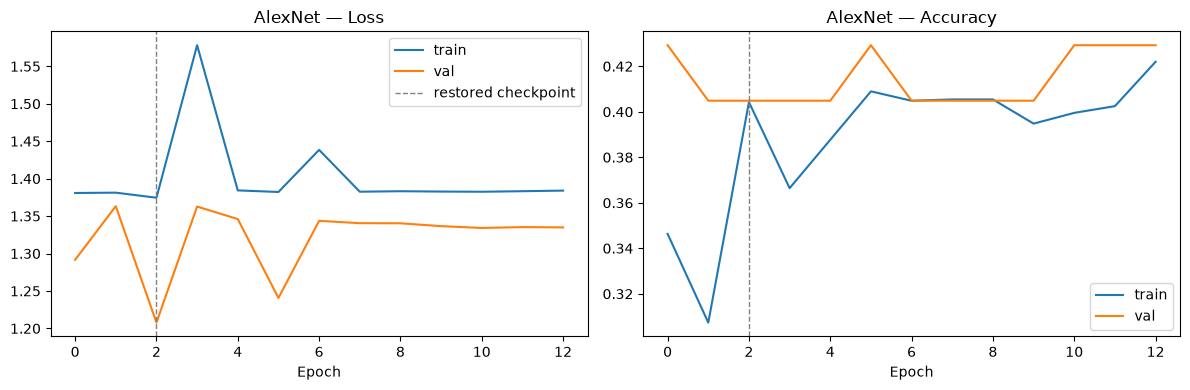

In [4]:
history = train_model(
    model, train_loader_arch, val_loader_arch, optimizer, scheduler,
    criterion, EPOCHS, EARLY_STOP_PATIENCE, "AlexNet", is_inception=False,
    accum_steps=accum_steps,
)
plot_training_curves(history, "AlexNet")

## Evaluate on the test set

[AlexNet] Test accuracy: 0.412


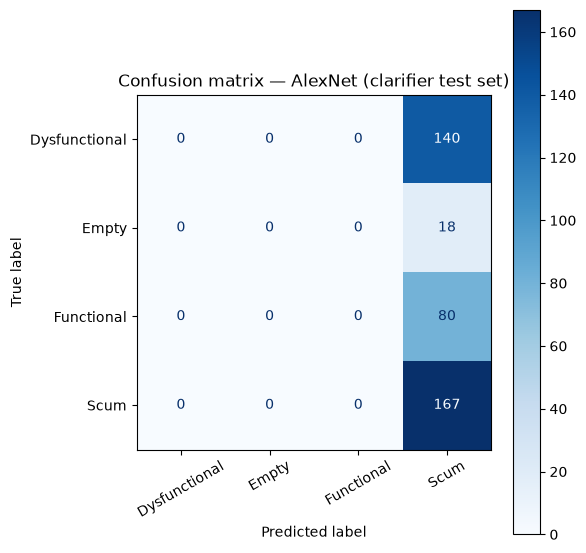

               precision    recall  f1-score   support

Dysfunctional      0.000     0.000     0.000       140
        Empty      0.000     0.000     0.000        18
   Functional      0.000     0.000     0.000        80
         Scum      0.412     1.000     0.584       167

     accuracy                          0.412       405
    macro avg      0.103     0.250     0.146       405
 weighted avg      0.170     0.412     0.241       405



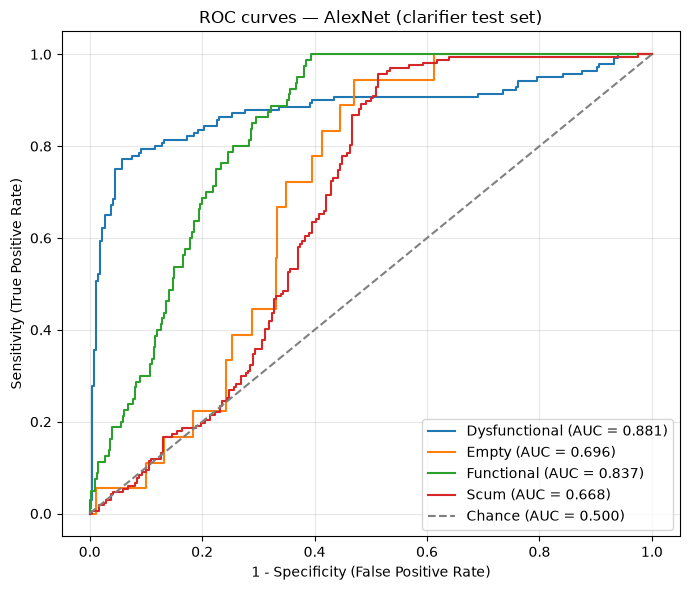

AUC (area under ROC curve) per class:
  Dysfunctional  : 0.881
  Empty          : 0.696
  Functional     : 0.837
  Scum           : 0.668

Mean AUC (over 4/4 classes with test examples): 0.771


(np.float64(0.4123456790123457),
 {'Dysfunctional': 0.8812129380053909,
  'Empty': 0.6962388745334481,
  'Functional': 0.8365384615384616,
  'Scum': 0.6682181854777839})

In [5]:
evaluate_and_record(
    model, test_loader_arch, "AlexNet", history,
    img_size=cfg["img_size"], hidden_layers=cfg["hidden_layers"], neurons=cfg["neurons"],
)

## Save results + model weights to disk

In [6]:
save_result("AlexNet", "alexnet")

Saved results to ../results/results_clarifier_alexnet_NoordelikeWerke.pkl


Saved model weights to ../models/clarifier_alexnet_cnn.pt
